##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class**

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold
  - The model only detects objects from the **COCO dataset (80 classes)**  


Saving crowded scene.jpg to crowded scene.jpg
Saving kitchen.webp to kitchen.webp
Saving low light.jpg to low light.jpg
Saving partially hidden bicycle.jpg to partially hidden bicycle.jpg
Saving sheeps.jpg to sheeps.jpg
Conversion done
Images renamed successfully



  0%|          | 0.00/16.0M [00:00<?, ?B/s]



100%|██████████| 15.4k/15.4k [00:00<00:00, 31.6MB/s]




  0%|          | 0.00/248M [00:00<?, ?B/s]
  6%|▋         | 1.00M/16.0M [00:01<00:20, 765kB/s]
 13%|█▎        | 2.00M/16.0M [00:01<00:09, 1.49MB/s]

  0%|          | 1.00M/248M [00:01<06:17, 687kB/s]
 19%|█▉        | 3.00M/16.0M [00:01<00:05, 2.37MB/s]
 31%|███▏      | 5.00M/16.0M [00:01<00:02, 4.37MB/s]

  1%|          | 2.00M/248M [00:01<03:12, 1.34MB/s]
 44%|████▍     | 7.00M/16.0M [00:02<00:01, 6.68MB/s]

  1%|          | 3.00M/248M [00:01<02:00, 2.13MB/s]
 56%|█████▋    | 9.00M/16.0M [00:02<00:00, 8.60MB/s]

  2%|▏         | 4.00M/248M [00:02<01:23, 3.08MB/s]
 69%|██████▉   | 11.0M/16.0M [00:02<00:00, 10.8MB/s]
 81%|████████▏ | 13.0M/16.0M [00:02<00:00, 12.0MB/s]
100%|██████████| 16.0M/16.0M [00:02<00:00, 6.53MB/s]


  2%|▏         | 5.00M/248M [00:02<01:22, 3.11MB/s]

  4%|▎         | 9.00M/248M [00:02<00:36, 6.79MB/s]

  5%|▌         | 13.0M/248M [00:02<00:26, 9.40MB/s]

  7%|▋         | 17.0M/248M [00:03<00:21, 11.3MB/s]

  8%|▊         | 20.0M/248M [00:03<00:20, 11.7MB/s]



Model loaded successfully

===== IMAGE 1 =====
Threshold = 0.5


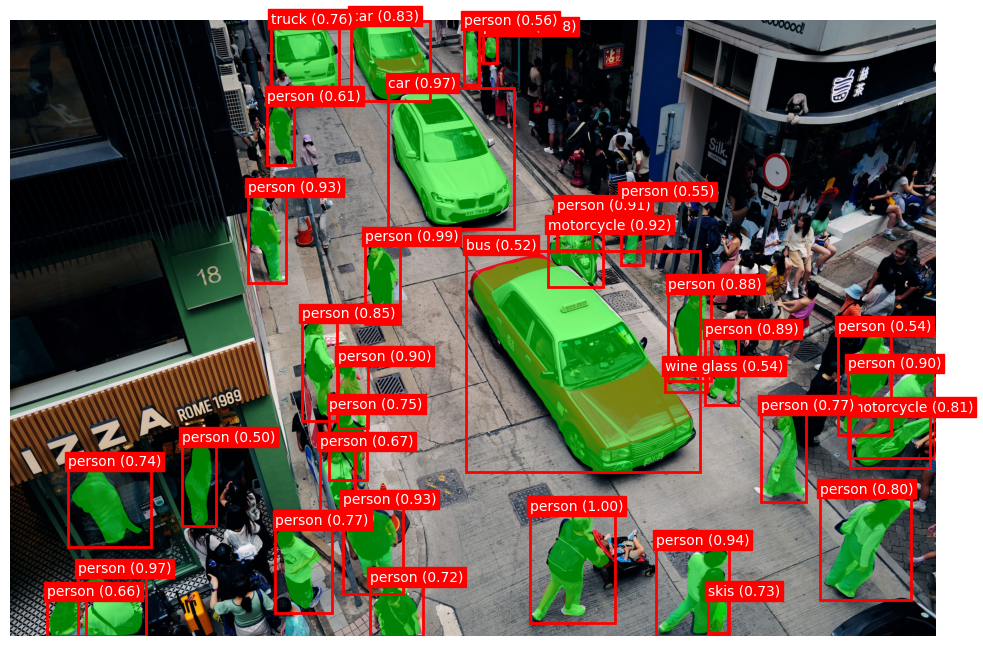

Threshold = 0.3


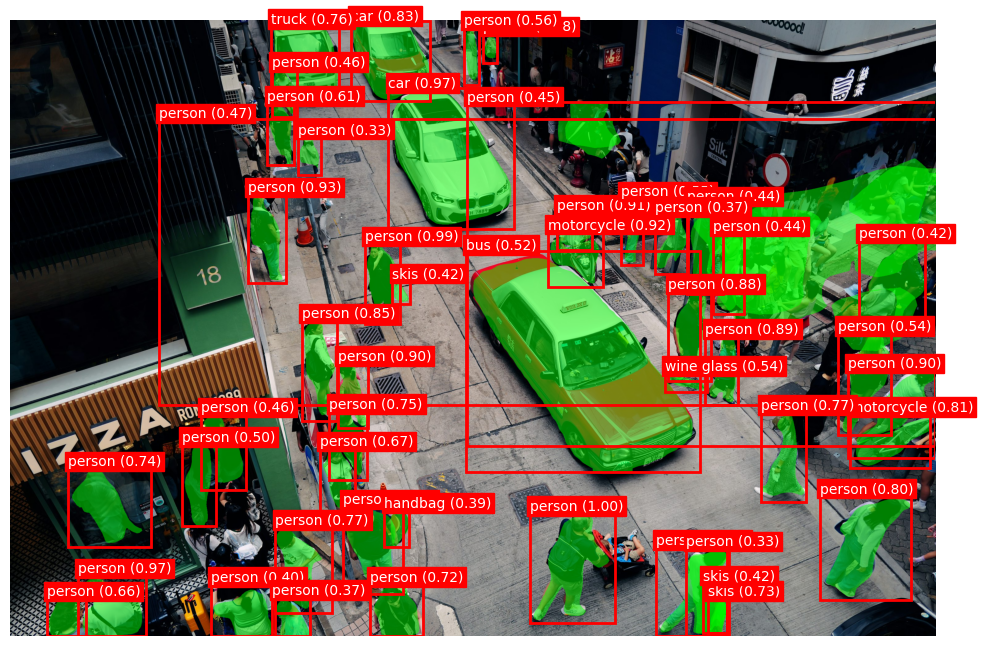


===== IMAGE 2 =====
Threshold = 0.5


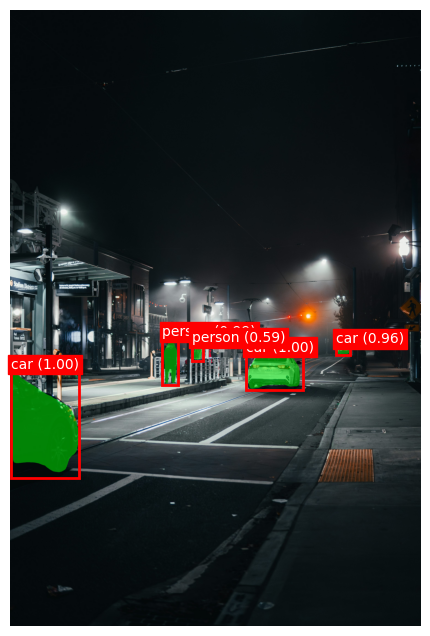

Threshold = 0.3


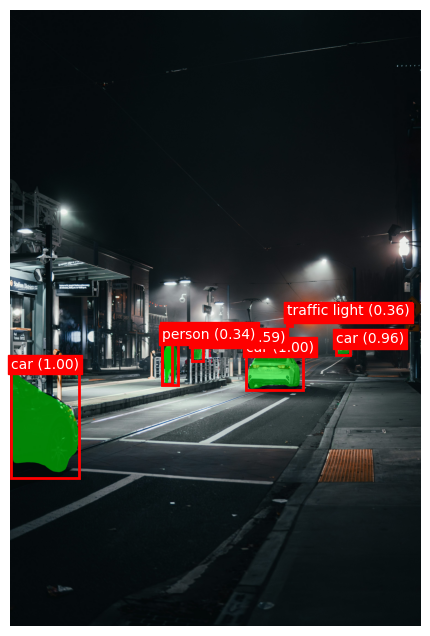


===== IMAGE 3 =====
Threshold = 0.5


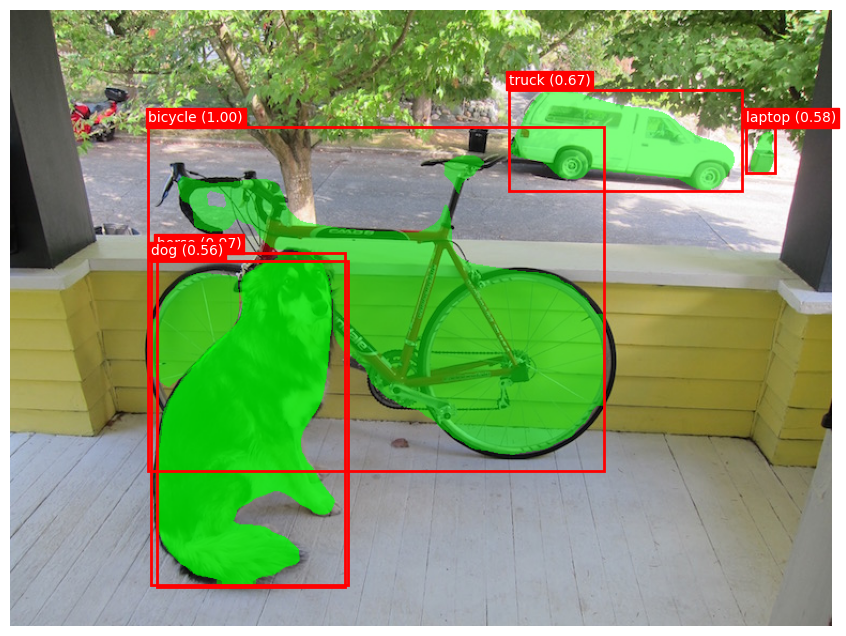

Threshold = 0.3


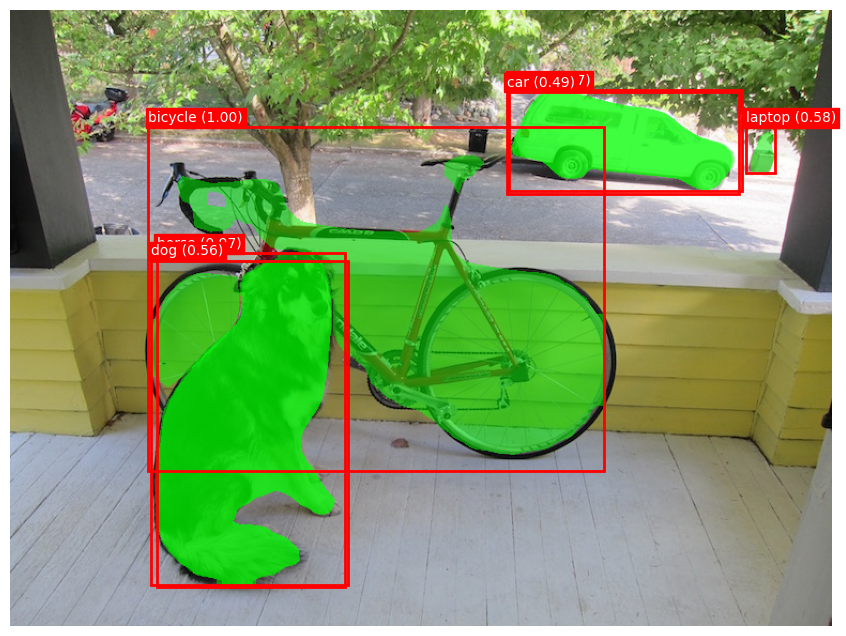


===== IMAGE 4 =====
Threshold = 0.5


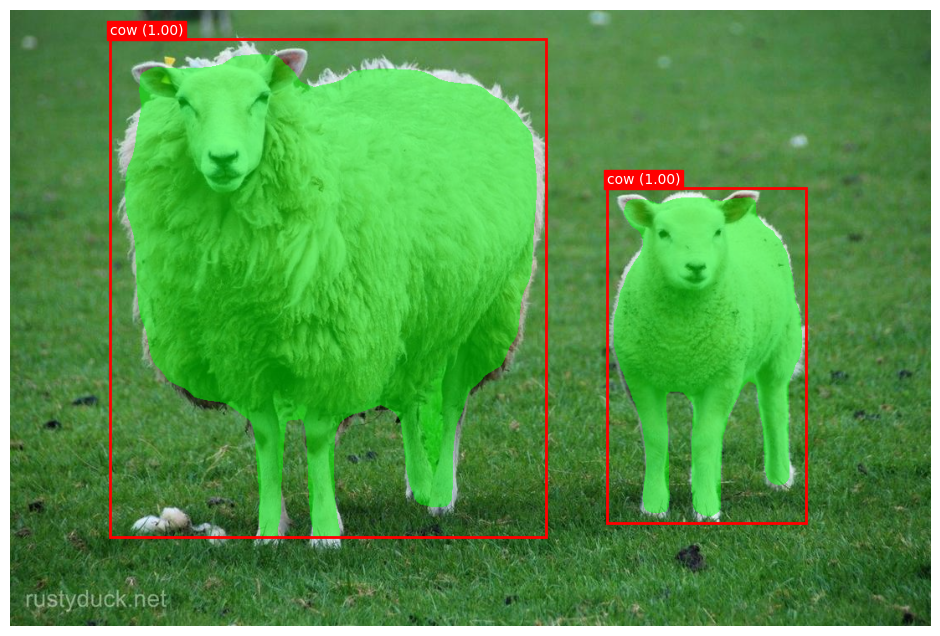

Threshold = 0.3


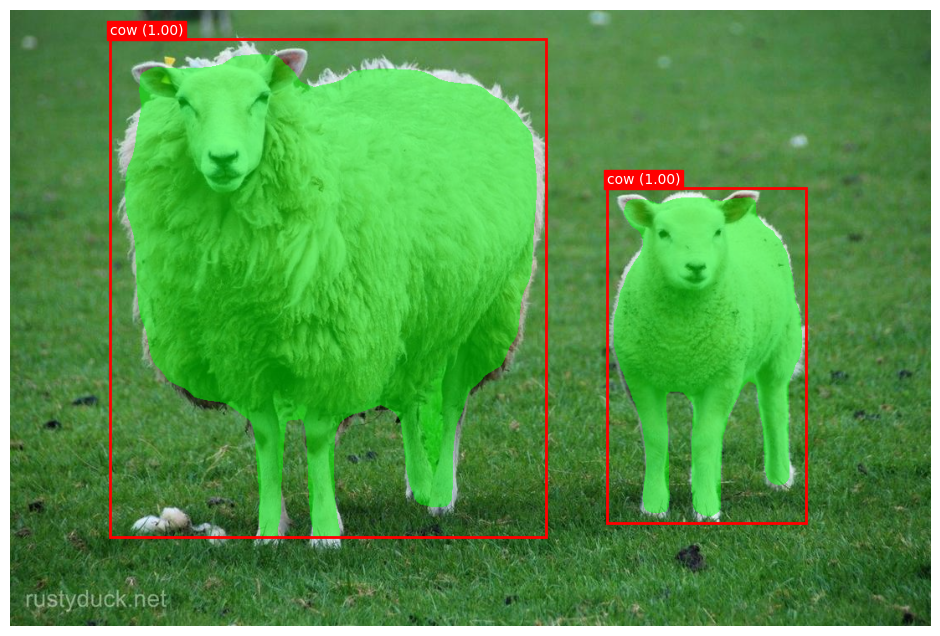


===== IMAGE 5 =====
Threshold = 0.5


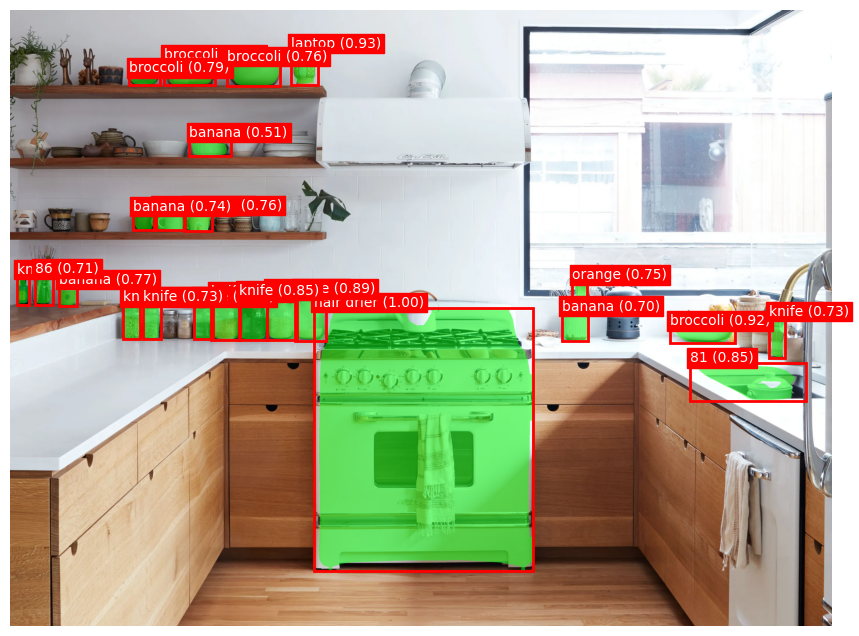

Threshold = 0.3


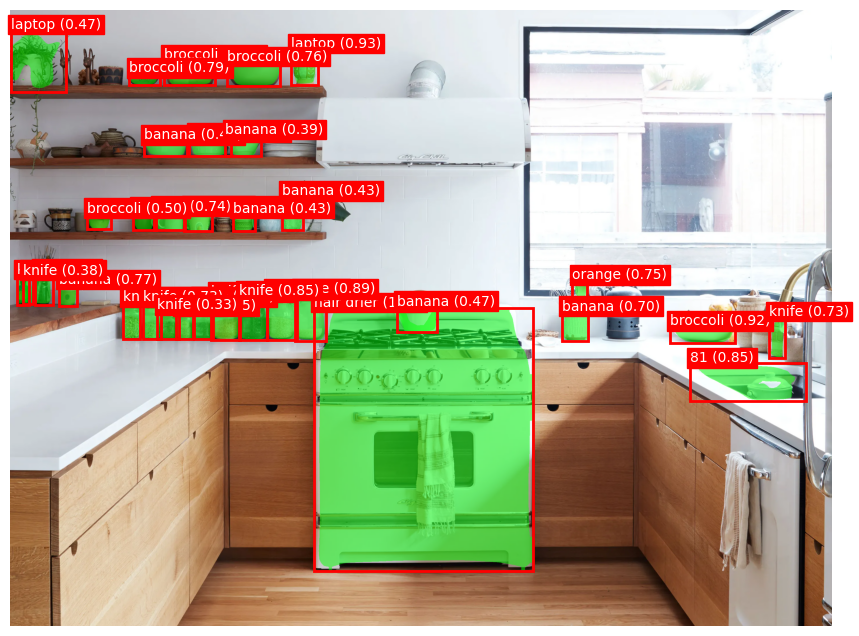

In [1]:
# ============================================================
# STEP 1 — Install
# ============================================================
!pip install -q kagglehub

# ============================================================
# STEP 2 — Upload Images
# ============================================================
from google.colab import files
uploaded = files.upload()


# ============================================================
# STEP 3 — Convert Images (if needed)
# ============================================================
from PIL import Image
import os

for file in os.listdir():
    if file.endswith((".png", ".webp", ".jpeg")):
        img = Image.open(file).convert("RGB")
        new_name = file.split(".")[0] + ".jpg"
        img.save(new_name)

print("Conversion done")

# ============================================================
# STEP 4 — Rename Images
# ============================================================
import os

os.rename("crowded scene.jpg", "img1.jpg")
os.rename("low light.jpg", "img2.jpg")
os.rename("partially hidden bicycle.jpg", "img3.jpg")
os.rename("sheeps.jpg", "img4.jpg")
os.rename("kitchen.webp", "img5.jpg")

print("Images renamed successfully")

# ============================================================
# STEP 5 — Imports
# ============================================================
import tensorflow as tf
import kagglehub
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# ============================================================
# STEP 6 — Load Mask R-CNN Model
# ============================================================
model_path = kagglehub.model_download(
    "tensorflow/mask-rcnn-inception-resnet-v2/tensorFlow2/1024x1024"
)

model_path = Path(model_path)

for p in [model_path, *model_path.rglob("*")]:
    if (p / "saved_model.pb").exists():
        saved_model_dir = p
        break

model = tf.saved_model.load(str(saved_model_dir))
infer = model.signatures["serving_default"]

print("Model loaded successfully")

# ============================================================
# STEP 7 — COCO Labels
# ============================================================
COCO_LABELS = [
'background','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse',
'sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase',
'frisbee','skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard',
'surfboard','tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl','banana',
'apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair','couch',
'potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
'hair drier','toothbrush'
]

# ============================================================
# STEP 8 — Helper Functions
# ============================================================
def load_image(path):
    image = Image.open(path).convert("RGB")
    image_np = np.array(image)
    input_tensor = tf.convert_to_tensor(image_np)[tf.newaxis, ...]
    return image_np, input_tensor

def run_inference(input_tensor):
    outputs = infer(input_tensor)
    return {k: v.numpy() for k, v in outputs.items()}

# ============================================================
# STEP 9 — Visualization (Boxes + Masks)  [CORRECTED]
# ============================================================
def visualize(image, outputs, threshold=0.5, mask_threshold=0.5):
    boxes = outputs["detection_boxes"][0]
    classes = outputs["detection_classes"][0].astype(int)
    scores = outputs["detection_scores"][0]
    masks = outputs.get("detection_masks", None)

    h, w = image.shape[:2]
    image_copy = image.copy().astype(np.float32)

    # ---------- draw masks correctly inside each bounding box ----------
    if masks is not None:
        for i in range(len(scores)):
            if scores[i] < threshold:
                continue

            y1, x1, y2, x2 = boxes[i]
            x1, x2 = int(x1 * w), int(x2 * w)
            y1, y2 = int(y1 * h), int(y2 * h)

            # Safety checks
            x1 = max(0, min(x1, w - 1))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h - 1))
            y2 = max(0, min(y2, h))

            if x2 <= x1 or y2 <= y1:
                continue

            # Mask for this detection is resized ONLY to the box size
            mask = masks[0][i]
            mask_resized = cv2.resize(mask, (x2 - x1, y2 - y1))
            mask_bin = mask_resized > mask_threshold

            roi = image_copy[y1:y2, x1:x2]
            green = np.array([0, 255, 0], dtype=np.float32)

            roi[mask_bin] = roi[mask_bin] * 0.5 + green * 0.5
            image_copy[y1:y2, x1:x2] = roi

    image_copy = np.clip(image_copy, 0, 255).astype(np.uint8)

    # ---------- show image ----------
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_copy)

    # ---------- draw boxes and labels ----------
    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        y1, x1, y2, x2 = boxes[i]
        x1, x2 = int(x1 * w), int(x2 * w)
        y1, y2 = int(y1 * h), int(y2 * h)

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        class_id = classes[i]
        label = COCO_LABELS[class_id] if 0 <= class_id < len(COCO_LABELS) else str(class_id)

        ax.text(
            x1, max(0, y1 - 5),
            f"{label} ({scores[i]:.2f})",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", edgecolor="red", pad=2)
        )

    plt.axis("off")
    plt.show()

# ============================================================
# STEP 10 — Run on All Images
# ============================================================
for i in range(1, 6):
    print(f"\n===== IMAGE {i} =====")

    image_np, input_tensor = load_image(f"img{i}.jpg")
    outputs = run_inference(input_tensor)

    print("Threshold = 0.5")
    visualize(image_np, outputs, threshold=0.5)

    print("Threshold = 0.3")
    visualize(image_np, outputs, threshold=0.3)